# Texas Housing Market Analysis

## Notebook 04: National Screening Validation

### Objective
This notebook compares the national BigQuery screening model against your existing Texas model and determine whether the two frameworks tell a consistent story.

In [2]:
from google.cloud import bigquery
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
# PROJECT PATHS

PROCESSED_DATA_DIR = Path("../data/processed")

decision_table = pd.read_csv(
    PROCESSED_DATA_DIR / "dallas_final_decision_table.csv"
)

print(decision_table.shape)
decision_table.head()

(9, 10)


,City,Long_Term_Fundamentals_Score,Fundamentals_Rank,Current_Market_Momentum_Score,Momentum_Rank,Pct_Rank_1,Pct_Top_3,Average_Rank,Robustness_Profile,Current_Market_Regime
0,Plano,42.94,6,75.61,1,32.93,81.62,2.31,Highly Robust,Relatively Stable
1,Melissa,62.50,2,54.61,5,19.91,74.69,2.84,Moderately Robust,Mixed / Transitional
2,Richardson,47.27,5,64.32,2,18.88,58.72,3.44,Moderately Robust,Relatively Stable
3,Celina,91.02,1,21.50,9,24.36,42.94,4.25,Moderately Robust,Demand Growth / Supply Pressure
4,McKinney,41.72,8,57.07,4,0.00,8.52,5.16,Consistently Lower Ranked,Mixed / Transitional


## 1. Load national BigQuery results

In [4]:
client = bigquery.Client(project="tx-market-analysis")

query = """
SELECT *
FROM `tx-market-analysis.market_data.final_decision_table`
ORDER BY national_robust_rank
"""

national_df = client.query(query).to_dataframe()

print(f"Eligible markets: {len(national_df):,}")
print(f"States represented: {national_df['state_code'].nunique()}")

national_df.head()

Eligible markets: 2,906
States represented: 49


,market_id,city,state_name,state_code,latitude,longitude,year,population,home_value,population_growth_1yr_pct,population_growth_5yr_pct,home_value_growth_1yr_pct,home_value_cagr_3yr_pct,home_value_cagr_5yr_pct,permitted_units,permits_per_1000_population,permit_growth_1yr_pct,homes_sold,homes_sold_growth_1yr_pct,avg_inventory,inventory_growth_1yr_pct,avg_months_of_supply,avg_sale_to_list_pct,activity_months,growth_score,demand_score,supply_score,baseline_score,growth_heavy_score,demand_heavy_score,supply_light_score,avg_scenario_score,baseline_rank,growth_heavy_rank,demand_heavy_rank,supply_light_rank,avg_rank,rank_range,rank_stddev,national_baseline_rank,national_robust_rank,state_baseline_rank,state_robust_rank,created_at
0,US-3468460,Somerville,New Jersey,NJ,NaN,NaN,2025,14665,"544,227.09",2.24,18.68,3.06,7.88,8.01,5,0.34,-64.29,332.00,3.43,16.08,5.46,1.80,102.59,12,89.31,79.52,79.13,83.34,84.85,82.40,83.89,83.62,2,1,4,1,2.00,3,1.22,2,1,2,1,2026-09-19 22:18:21.483951+00:00
1,US-3482120,Woodbury,New Jersey,NJ,NaN,NaN,2025,10130,"331,899.88",0.18,1.78,4.72,6.85,9.67,0,0.00,NaN,419.00,25.83,26.58,-0.31,2.33,101.13,12,74.11,88.22,93.73,83.96,81.29,84.82,82.43,83.12,1,4,1,3,2.25,3,1.30,1,2,1,2,2026-09-19 22:18:21.483951+00:00
2,US-3479040,Westfield,New Jersey,NJ,NaN,NaN,2025,32595,"1,242,304.02",0.92,5.52,5.53,7.22,7.87,4,0.12,-76.47,"1,026.00",2.19,31.75,-14.96,1.24,107.02,12,78.98,80.13,93.49,83.01,81.50,81.79,80.95,81.82,3,3,7,7,5.00,4,2.00,3,3,3,3,2026-09-19 22:18:21.483951+00:00
3,US-3473020,Tinton Falls,New Jersey,NJ,NaN,NaN,2025,19539,"626,558.45",0.52,2.28,3.09,5.92,8.65,69,3.53,-13.75,884.00,19.95,28.17,-14.65,1.17,101.13,12,74.87,94.51,62.93,78.76,78.97,83.88,82.51,81.03,9,12,2,2,6.25,10,4.38,9,4,4,4,2026-09-19 22:18:21.483951+00:00
4,US-3423910,Florham Park,New Jersey,NJ,NaN,NaN,2025,14456,"990,591.32",0.27,14.76,7.34,7.62,7.13,54,3.74,-15.63,350.00,7.36,12.50,-23.47,1.42,104.49,12,80.41,87.62,61.98,78.33,79.81,81.61,81.81,80.39,12,9,8,4,8.25,8,2.86,12,5,5,5,2026-09-19 22:18:21.483951+00:00


## 2. Load local Dallas model

In [5]:
original_markets = [
    "Plano",
    "Melissa",
    "Richardson",
    "Celina",
    "McKinney",
    "Frisco",
    "Princeton",
    "Prosper",
    "Anna",
]

national_nine = (
    national_df[
        (national_df["state_code"] == "TX")
        & (national_df["city"].isin(original_markets))
    ]
    .copy()
    .sort_values("state_robust_rank")
)

print(f"Matched markets: {len(national_nine)}")

national_nine[
    [
        "city",
        "state_robust_rank",
        "national_robust_rank",
        "population",
        "home_value",
        "population_growth_5yr_pct",
        "home_value_cagr_5yr_pct",
        "growth_score",
        "demand_score",
        "supply_score",
        "baseline_score",
        "avg_scenario_score",
        "rank_range",
        "rank_stddev",
    ]
]

Matched markets: 9


,city,state_robust_rank,national_robust_rank,population,home_value,population_growth_5yr_pct,home_value_cagr_5yr_pct,growth_score,demand_score,supply_score,baseline_score,avg_scenario_score,rank_range,rank_stddev
1224,Prosper,23,1225,45605,"792,319.84",47.93,8.86,94.63,20.63,25.25,51.39,52.83,1564,559.01
1226,Frisco,25,1227,236955,"662,448.02",16.87,8.11,89.54,32.32,8.92,49.35,52.83,1241,480.19
1247,McKinney,29,1248,236001,"491,666.12",19.49,6.84,78.42,42.28,11.92,49.14,52.71,770,336.94
1567,Plano,50,1568,293028,"508,396.61",2.31,6.45,55.56,45.48,44.17,49.18,49.55,193,69.37
2025,Celina,88,2026,64427,"548,851.85",257.27,7.88,89.64,11.67,4.99,41.19,43.72,1349,509.97
2115,Princeton,96,2116,43524,"305,340.85",148.69,3.75,52.43,46.90,11.37,40.23,43.47,488,180.04
2180,Melissa,109,2181,29969,"441,184.96",109.00,6.33,72.44,13.41,33.73,42.10,41.80,930,332.11
2375,Anna,135,2376,35245,"354,960.20",100.07,4.72,56.90,32.52,11.38,36.99,39.45,451,184.28
2570,Richardson,176,2571,118542,"440,471.15",-0.65,5.97,35.70,40.45,24.59,34.58,35.85,194,77.44


In [6]:
local_df = pd.read_csv(
    PROCESSED_DATA_DIR / "tx_local_model_scores.csv"
)

print(local_df.shape)
local_df

(9, 10)


,City,Long_Term_Fundamentals_Score,Fundamentals_Rank,Current_Market_Momentum_Score,Momentum_Rank,Pct_Rank_1,Pct_Top_3,Average_Rank,Robustness_Profile,Current_Market_Regime
0,Plano,42.94,6,75.61,1,32.93,81.62,2.31,Highly Robust,Relatively Stable
1,Melissa,62.50,2,54.61,5,19.91,74.69,2.84,Moderately Robust,Mixed / Transitional
2,Richardson,47.27,5,64.32,2,18.88,58.72,3.44,Moderately Robust,Relatively Stable
3,Celina,91.02,1,21.50,9,24.36,42.94,4.25,Moderately Robust,Demand Growth / Supply Pressure
4,McKinney,41.72,8,57.07,4,0.00,8.52,5.16,Consistently Lower Ranked,Mixed / Transitional
5,Frisco,48.93,4,47.92,6,0.10,11.93,5.66,Consistently Lower Ranked,Relatively Stable
6,Princeton,31.07,9,58.98,3,3.80,19.88,6.58,Weight Sensitive,Recovery / Repricing
7,Prosper,57.26,3,31.46,8,0.02,1.14,7.21,Consistently Lower Ranked,Mixed / Transitional
8,Anna,42.75,7,36.01,7,0.00,0.56,7.56,Consistently Lower Ranked,Demand Growth / Supply Pressure


## Merge the modules

In [7]:
comparison = national_nine.merge(
    local_df,
    left_on="city",
    right_on="City",
    how="left",
)

print(f"Comparison rows: {len(comparison)}")
print(f"Missing local matches: {comparison['City'].isna().sum()}")

comparison[
    [
        "city",
        "state_robust_rank",
        "national_robust_rank",
        "Long_Term_Fundamentals_Score",
        "Fundamentals_Rank",
        "Current_Market_Momentum_Score",
        "Momentum_Rank",
        "Average_Rank",
        "Robustness_Profile",
        "Current_Market_Regime",
    ]
].sort_values("state_robust_rank")

Comparison rows: 9
Missing local matches: 0


,city,state_robust_rank,national_robust_rank,Long_Term_Fundamentals_Score,Fundamentals_Rank,Current_Market_Momentum_Score,Momentum_Rank,Average_Rank,Robustness_Profile,Current_Market_Regime
0,Prosper,23,1225,57.26,3,31.46,8,7.21,Consistently Lower Ranked,Mixed / Transitional
1,Frisco,25,1227,48.93,4,47.92,6,5.66,Consistently Lower Ranked,Relatively Stable
2,McKinney,29,1248,41.72,8,57.07,4,5.16,Consistently Lower Ranked,Mixed / Transitional
3,Plano,50,1568,42.94,6,75.61,1,2.31,Highly Robust,Relatively Stable
4,Celina,88,2026,91.02,1,21.50,9,4.25,Moderately Robust,Demand Growth / Supply Pressure
5,Princeton,96,2116,31.07,9,58.98,3,6.58,Weight Sensitive,Recovery / Repricing
6,Melissa,109,2181,62.50,2,54.61,5,2.84,Moderately Robust,Mixed / Transitional
7,Anna,135,2376,42.75,7,36.01,7,7.56,Consistently Lower Ranked,Demand Growth / Supply Pressure
8,Richardson,176,2571,47.27,5,64.32,2,3.44,Moderately Robust,Relatively Stable


In [8]:
# Comparable local robustness rank

comparison["Local_Robust_Rank"] = (
    comparison["Average_Rank"]
    .rank(method="min")
    .astype(int)
)

comparison[
    [
        "city",
        "state_robust_rank",
        "Local_Robust_Rank",
        "Average_Rank",
        "Robustness_Profile",
    ]
].sort_values("Local_Robust_Rank")

,city,state_robust_rank,Local_Robust_Rank,Average_Rank,Robustness_Profile
3,Plano,50,1,2.31,Highly Robust
6,Melissa,109,2,2.84,Moderately Robust
8,Richardson,176,3,3.44,Moderately Robust
4,Celina,88,4,4.25,Moderately Robust
2,McKinney,29,5,5.16,Consistently Lower Ranked
1,Frisco,25,6,5.66,Consistently Lower Ranked
5,Princeton,96,7,6.58,Weight Sensitive
0,Prosper,23,8,7.21,Consistently Lower Ranked
7,Anna,135,9,7.56,Consistently Lower Ranked


In [9]:
# Rank agreement

spearman_corr = comparison[
    ["state_robust_rank", "Local_Robust_Rank"]
].corr(method="spearman").iloc[0, 1]

print(f"Spearman rank correlation: {spearman_corr:.3f}")

Spearman rank correlation: -0.183


In [10]:
# Rank disagreement

comparison["rank_difference"] = (
    comparison["state_robust_rank"]
    - comparison["Local_Robust_Rank"]
).abs()

comparison[
    [
        "city",
        "state_robust_rank",
        "Local_Robust_Rank",
        "rank_difference",
        "Robustness_Profile",
        "Current_Market_Regime",
    ]
].sort_values(
    "rank_difference",
    ascending=False
)

,city,state_robust_rank,Local_Robust_Rank,rank_difference,Robustness_Profile,Current_Market_Regime
8,Richardson,176,3,173,Moderately Robust,Relatively Stable
7,Anna,135,9,126,Consistently Lower Ranked,Demand Growth / Supply Pressure
6,Melissa,109,2,107,Moderately Robust,Mixed / Transitional
5,Princeton,96,7,89,Weight Sensitive,Recovery / Repricing
4,Celina,88,4,84,Moderately Robust,Demand Growth / Supply Pressure
3,Plano,50,1,49,Highly Robust,Relatively Stable
2,McKinney,29,5,24,Consistently Lower Ranked,Mixed / Transitional
1,Frisco,25,6,19,Consistently Lower Ranked,Relatively Stable
0,Prosper,23,8,15,Consistently Lower Ranked,Mixed / Transitional


## Create a national rank model within the original nine

In [11]:
comparison["National_Among_9_Rank"] = (
    comparison["avg_scenario_score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

comparison[
    [
        "city",
        "state_robust_rank",
        "National_Among_9_Rank",
        "Local_Robust_Rank",
        "avg_scenario_score",
        "Average_Rank",
    ]
].sort_values("National_Among_9_Rank")

,city,state_robust_rank,National_Among_9_Rank,Local_Robust_Rank,avg_scenario_score,Average_Rank
0,Prosper,23,1,8,52.83,7.21
1,Frisco,25,1,6,52.83,5.66
2,McKinney,29,3,5,52.71,5.16
3,Plano,50,4,1,49.55,2.31
4,Celina,88,5,4,43.72,4.25
5,Princeton,96,6,7,43.47,6.58
6,Melissa,109,7,2,41.80,2.84
7,Anna,135,8,9,39.45,7.56
8,Richardson,176,9,3,35.85,3.44


In [12]:
# Recalculate Spearman correlation

spearman_9 = comparison[
    ["National_Among_9_Rank", "Local_Robust_Rank"]
].corr(method="spearman").iloc[0, 1]

print(
    f"Spearman correlation within the same 9-market universe: "
    f"{spearman_9:.3f}"
)

Spearman correlation within the same 9-market universe: -0.167


In [13]:
# Calculate nine-market disagreement

comparison["Within_9_Rank_Difference"] = (
    comparison["National_Among_9_Rank"]
    - comparison["Local_Robust_Rank"]
).abs()

rank_comparison = comparison[
    [
        "city",
        "National_Among_9_Rank",
        "Local_Robust_Rank",
        "Within_9_Rank_Difference",
        "state_robust_rank",
        "national_robust_rank",
        "Robustness_Profile",
        "Current_Market_Regime",
    ]
].sort_values(
    ["Within_9_Rank_Difference", "National_Among_9_Rank"],
    ascending=[False, True],
)

rank_comparison

,city,National_Among_9_Rank,Local_Robust_Rank,Within_9_Rank_Difference,state_robust_rank,national_robust_rank,Robustness_Profile,Current_Market_Regime
0,Prosper,1,8,7,23,1225,Consistently Lower Ranked,Mixed / Transitional
8,Richardson,9,3,6,176,2571,Moderately Robust,Relatively Stable
1,Frisco,1,6,5,25,1227,Consistently Lower Ranked,Relatively Stable
6,Melissa,7,2,5,109,2181,Moderately Robust,Mixed / Transitional
3,Plano,4,1,3,50,1568,Highly Robust,Relatively Stable
2,McKinney,3,5,2,29,1248,Consistently Lower Ranked,Mixed / Transitional
4,Celina,5,4,1,88,2026,Moderately Robust,Demand Growth / Supply Pressure
5,Princeton,6,7,1,96,2116,Weight Sensitive,Recovery / Repricing
7,Anna,8,9,1,135,2376,Consistently Lower Ranked,Demand Growth / Supply Pressure


In [14]:
# Compare model dimensions

model_comparison = comparison[
    [
        "city",

        # National model
        "growth_score",
        "demand_score",
        "supply_score",
        "avg_scenario_score",

        # Local model
        "Long_Term_Fundamentals_Score",
        "Current_Market_Momentum_Score",

        # Rankings
        "National_Among_9_Rank",
        "Local_Robust_Rank",

        # Local interpretation
        "Robustness_Profile",
        "Current_Market_Regime",
    ]
].sort_values("National_Among_9_Rank")

model_comparison

,city,growth_score,demand_score,supply_score,avg_scenario_score,Long_Term_Fundamentals_Score,Current_Market_Momentum_Score,National_Among_9_Rank,Local_Robust_Rank,Robustness_Profile,Current_Market_Regime
0,Prosper,94.63,20.63,25.25,52.83,57.26,31.46,1,8,Consistently Lower Ranked,Mixed / Transitional
1,Frisco,89.54,32.32,8.92,52.83,48.93,47.92,1,6,Consistently Lower Ranked,Relatively Stable
2,McKinney,78.42,42.28,11.92,52.71,41.72,57.07,3,5,Consistently Lower Ranked,Mixed / Transitional
3,Plano,55.56,45.48,44.17,49.55,42.94,75.61,4,1,Highly Robust,Relatively Stable
4,Celina,89.64,11.67,4.99,43.72,91.02,21.50,5,4,Moderately Robust,Demand Growth / Supply Pressure
5,Princeton,52.43,46.90,11.37,43.47,31.07,58.98,6,7,Weight Sensitive,Recovery / Repricing
6,Melissa,72.44,13.41,33.73,41.80,62.50,54.61,7,2,Moderately Robust,Mixed / Transitional
7,Anna,56.90,32.52,11.38,39.45,42.75,36.01,8,9,Consistently Lower Ranked,Demand Growth / Supply Pressure
8,Richardson,35.70,40.45,24.59,35.85,47.27,64.32,9,3,Moderately Robust,Relatively Stable


In [15]:
# Convert Texas ranks to percentiles

texas_market_count = len(
    national_df[national_df["state_code"] == "TX"]
)

comparison["Texas_Robust_Percentile"] = (
    1
    - (
        (comparison["state_robust_rank"] - 1)
        / (texas_market_count - 1)
    )
) * 100

comparison[
    [
        "city",
        "state_robust_rank",
        "Texas_Robust_Percentile",
        "National_Among_9_Rank",
        "Local_Robust_Rank",
    ]
].sort_values("state_robust_rank")

,city,state_robust_rank,Texas_Robust_Percentile,National_Among_9_Rank,Local_Robust_Rank
0,Prosper,23,91.09,1,8
1,Frisco,25,90.28,1,6
2,McKinney,29,88.66,3,5
3,Plano,50,80.16,4,1
4,Celina,88,64.78,5,4
5,Princeton,96,61.54,6,7
6,Melissa,109,56.28,7,2
7,Anna,135,45.75,8,9
8,Richardson,176,29.15,9,3


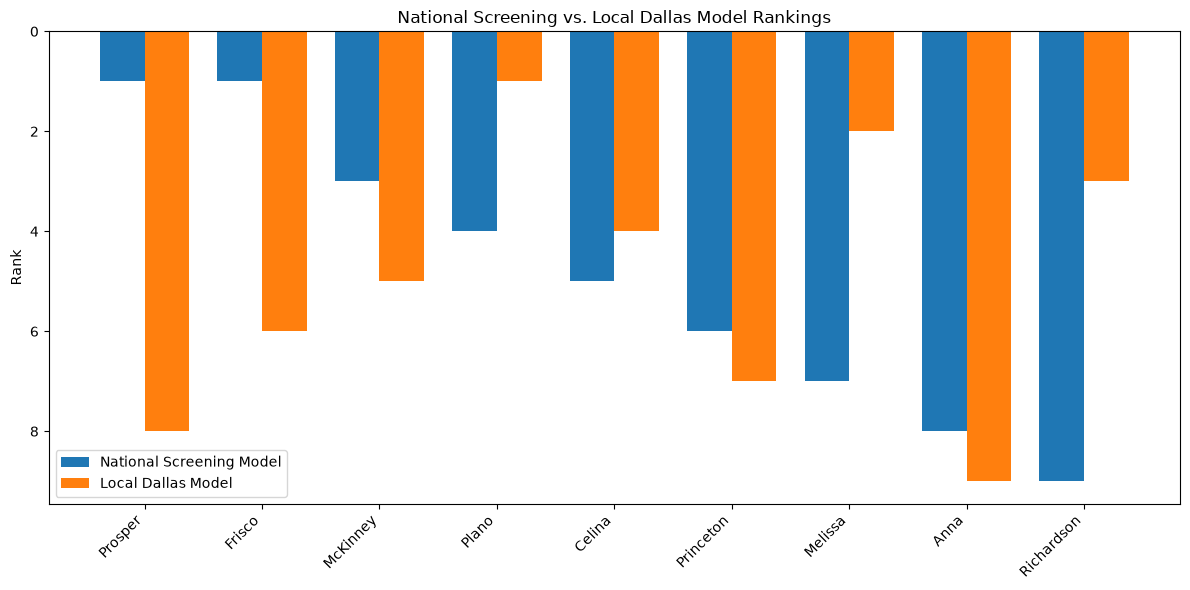

In [16]:
# National vs. Local rank comparison

plot_df = (
    comparison[
        [
            "city",
            "National_Among_9_Rank",
            "Local_Robust_Rank",
        ]
    ]
    .sort_values("National_Among_9_Rank")
    .copy()
)

x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width / 2,
    plot_df["National_Among_9_Rank"],
    width,
    label="National Screening Model",
)

ax.bar(
    x + width / 2,
    plot_df["Local_Robust_Rank"],
    width,
    label="Local Dallas Model",
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["city"],
    rotation=45,
    ha="right",
)

ax.set_ylabel("Rank")
ax.set_title(
    "National Screening vs. Local Dallas Model Rankings"
)

ax.invert_yaxis()
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
# Add rank-direction fields

comparison["Rank_Gap"] = (
    comparison["National_Among_9_Rank"]
    - comparison["Local_Robust_Rank"]
)

comparison["Model_View"] = np.select(
    [
        comparison["Rank_Gap"] <= -3,
        comparison["Rank_Gap"] >= 3,
    ],
    [
        "National model more favorable",
        "Local model more favorable",
    ],
    default="Broad agreement",
)

In [18]:
comparison[
    [
        "city",
        "National_Among_9_Rank",
        "Local_Robust_Rank",
        "Rank_Gap",
        "Model_View",
    ]
].sort_values("Rank_Gap")

,city,National_Among_9_Rank,Local_Robust_Rank,Rank_Gap,Model_View
0,Prosper,1,8,-7,National model more favorable
1,Frisco,1,6,-5,National model more favorable
2,McKinney,3,5,-2,Broad agreement
5,Princeton,6,7,-1,Broad agreement
7,Anna,8,9,-1,Broad agreement
4,Celina,5,4,1,Broad agreement
3,Plano,4,1,3,Local model more favorable
6,Melissa,7,2,5,Local model more favorable
8,Richardson,9,3,6,Local model more favorable


In [19]:
# Create percentile scores

comparison["National_Screening_Percentile"] = (
    comparison["avg_scenario_score"]
    .rank(pct=True)
    * 100
)

comparison["Local_Model_Percentile"] = (
    comparison["Average_Rank"]
    .rank(pct=True, ascending=False)
    * 100
)

In [20]:
# Classify markets

national_median = comparison["National_Screening_Percentile"].median()
local_median = comparison["Local_Model_Percentile"].median()

comparison["Market_Quadrant"] = np.select(
    [
        (
            comparison["National_Screening_Percentile"] >= national_median
        )
        & (
            comparison["Local_Model_Percentile"] >= local_median
        ),

        (
            comparison["National_Screening_Percentile"] >= national_median
        )
        & (
            comparison["Local_Model_Percentile"] < local_median
        ),

        (
            comparison["National_Screening_Percentile"] < national_median
        )
        & (
            comparison["Local_Model_Percentile"] >= local_median
        ),
    ],
    [
        "Strong in Both",
        "Long-Term Strength / Weak Current Conditions",
        "Current Strength / Weaker Structural Score",
    ],
    default="Weaker in Both",
)

In [21]:
comparison[
    [
        "city",
        "National_Screening_Percentile",
        "Local_Model_Percentile",
        "Market_Quadrant",
    ]
].sort_values(
    "National_Screening_Percentile",
    ascending=False,
)

,city,National_Screening_Percentile,Local_Model_Percentile,Market_Quadrant
0,Prosper,94.44,22.22,Long-Term Strength / Weak Current Conditions
1,Frisco,94.44,44.44,Long-Term Strength / Weak Current Conditions
2,McKinney,77.78,55.56,Strong in Both
3,Plano,66.67,100.00,Strong in Both
4,Celina,55.56,66.67,Strong in Both
5,Princeton,44.44,33.33,Weaker in Both
6,Melissa,33.33,88.89,Current Strength / Weaker Structural Score
7,Anna,22.22,11.11,Weaker in Both
8,Richardson,11.11,77.78,Current Strength / Weaker Structural Score


## Compare: National vs Local Screening Percentile

Saved: ../data/processed/structural_vs_local_market_strength.png


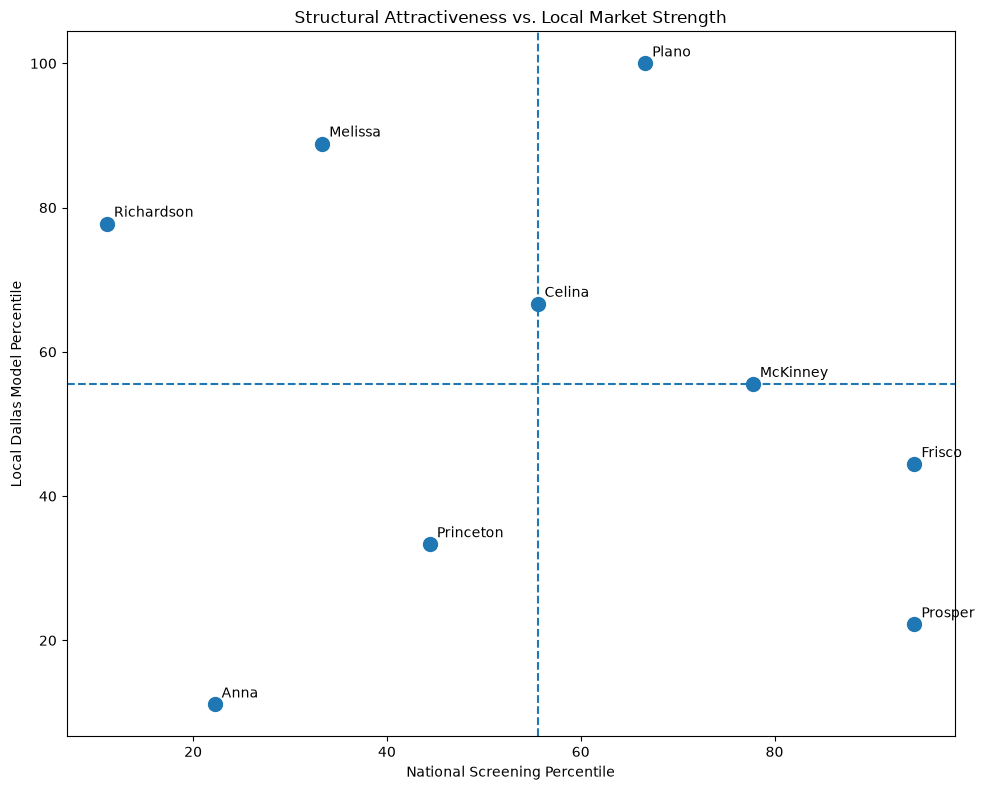

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    comparison["National_Screening_Percentile"],
    comparison["Local_Model_Percentile"],
    s=100,
)

for _, row in comparison.iterrows():
    ax.annotate(
        row["city"],
        (
            row["National_Screening_Percentile"],
            row["Local_Model_Percentile"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

ax.axvline(
    comparison["National_Screening_Percentile"].median(),
    linestyle="--",
)

ax.axhline(
    comparison["Local_Model_Percentile"].median(),
    linestyle="--",
)

ax.set_xlabel("National Screening Percentile")
ax.set_ylabel("Local Dallas Model Percentile")
ax.set_title(
    "Structural Attractiveness vs. Local Market Strength"
)

plt.tight_layout()

scatter_path = (
    PROCESSED_DATA_DIR
    / "structural_vs_local_market_strength.png"
)

plt.savefig(
    scatter_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved: {scatter_path}")

plt.show()

In [23]:
# Reconciliation

reconciliation = comparison[
    [
        "city",

        "National_Among_9_Rank",
        "Local_Robust_Rank",
        "Rank_Gap",

        "growth_score",
        "demand_score",
        "supply_score",

        "Long_Term_Fundamentals_Score",
        "Current_Market_Momentum_Score",

        "Robustness_Profile",
        "Current_Market_Regime",

        "Market_Quadrant",
    ]
].copy()

reconciliation.sort_values(
    "National_Among_9_Rank"
)

,city,National_Among_9_Rank,Local_Robust_Rank,Rank_Gap,growth_score,demand_score,supply_score,Long_Term_Fundamentals_Score,Current_Market_Momentum_Score,Robustness_Profile,Current_Market_Regime,Market_Quadrant
0,Prosper,1,8,-7,94.63,20.63,25.25,57.26,31.46,Consistently Lower Ranked,Mixed / Transitional,Long-Term Strength / Weak Current Conditions
1,Frisco,1,6,-5,89.54,32.32,8.92,48.93,47.92,Consistently Lower Ranked,Relatively Stable,Long-Term Strength / Weak Current Conditions
2,McKinney,3,5,-2,78.42,42.28,11.92,41.72,57.07,Consistently Lower Ranked,Mixed / Transitional,Strong in Both
3,Plano,4,1,3,55.56,45.48,44.17,42.94,75.61,Highly Robust,Relatively Stable,Strong in Both
4,Celina,5,4,1,89.64,11.67,4.99,91.02,21.50,Moderately Robust,Demand Growth / Supply Pressure,Strong in Both
5,Princeton,6,7,-1,52.43,46.90,11.37,31.07,58.98,Weight Sensitive,Recovery / Repricing,Weaker in Both
6,Melissa,7,2,5,72.44,13.41,33.73,62.50,54.61,Moderately Robust,Mixed / Transitional,Current Strength / Weaker Structural Score
7,Anna,8,9,-1,56.90,32.52,11.38,42.75,36.01,Consistently Lower Ranked,Demand Growth / Supply Pressure,Weaker in Both
8,Richardson,9,3,6,35.70,40.45,24.59,47.27,64.32,Moderately Robust,Relatively Stable,Current Strength / Weaker Structural Score


**Note:** Model agreement: The national screening model and local Dallas model produced a Spearman rank correlation of -0.167 across the same nine markets, indicating little rank agreement. This is consistent with their different objectives: the national model emphasizes structural growth, appreciation, demand, and supply conditions relative to a broad U.S. universe, while the local model incorporates Dallas-specific fundamentals, current momentum, market regimes, and Monte Carlo ranking robustness. Accordingly, the two models are treated as complementary rather than interchangeable.

## Model Reconciliation

The national screening model and the Dallas-specific model provide complementary
rather than interchangeable views of market attractiveness.

The national model emphasizes structural characteristics such as long-term population
growth, home-value appreciation, demand conditions, and supply pressure across a broad
U.S. market universe.

The local Dallas model places greater emphasis on Dallas-specific fundamentals,
current market momentum, market regime, and Monte Carlo ranking robustness.

The two models show weak rank agreement across the same nine markets
(Spearman correlation = -0.167), indicating that structural attractiveness and
current local-market strength are distinct dimensions.

### Market Groups

- **Strong in Both:** Plano, Celina, McKinney
- **Long-Term Strength / Weak Current Conditions:** Prosper, Frisco
- **Current Strength / Weaker Structural Score:** Melissa, Richardson
- **Weaker in Both:** Princeton, Anna

These classifications are relative to the nine-market comparison universe and should
be interpreted as screening categories rather than investment recommendations.

In [24]:
# Final Reconciliation Table

final_validation_table = comparison[
    [
        "city",
        "National_Among_9_Rank",
        "Local_Robust_Rank",
        "Rank_Gap",
        "Texas_Robust_Percentile",
        "growth_score",
        "demand_score",
        "supply_score",
        "Long_Term_Fundamentals_Score",
        "Current_Market_Momentum_Score",
        "Robustness_Profile",
        "Current_Market_Regime",
        "Market_Quadrant",
    ]
].copy()

final_validation_table = final_validation_table.rename(
    columns={
        "city": "City",
        "National_Among_9_Rank": "National_Model_Rank",
        "Local_Robust_Rank": "Local_Model_Rank",
        "Rank_Gap": "Rank_Gap",
        "Texas_Robust_Percentile": "Texas_Percentile",
        "growth_score": "National_Growth_Score",
        "demand_score": "National_Demand_Score",
        "supply_score": "National_Supply_Score",
    }
)

final_validation_table = (
    final_validation_table
    .sort_values("National_Model_Rank")
    .reset_index(drop=True)
)

final_validation_table

,City,National_Model_Rank,Local_Model_Rank,Rank_Gap,Texas_Percentile,National_Growth_Score,National_Demand_Score,National_Supply_Score,Long_Term_Fundamentals_Score,Current_Market_Momentum_Score,Robustness_Profile,Current_Market_Regime,Market_Quadrant
0,Prosper,1,8,-7,91.09,94.63,20.63,25.25,57.26,31.46,Consistently Lower Ranked,Mixed / Transitional,Long-Term Strength / Weak Current Conditions
1,Frisco,1,6,-5,90.28,89.54,32.32,8.92,48.93,47.92,Consistently Lower Ranked,Relatively Stable,Long-Term Strength / Weak Current Conditions
2,McKinney,3,5,-2,88.66,78.42,42.28,11.92,41.72,57.07,Consistently Lower Ranked,Mixed / Transitional,Strong in Both
3,Plano,4,1,3,80.16,55.56,45.48,44.17,42.94,75.61,Highly Robust,Relatively Stable,Strong in Both
4,Celina,5,4,1,64.78,89.64,11.67,4.99,91.02,21.50,Moderately Robust,Demand Growth / Supply Pressure,Strong in Both
5,Princeton,6,7,-1,61.54,52.43,46.90,11.37,31.07,58.98,Weight Sensitive,Recovery / Repricing,Weaker in Both
6,Melissa,7,2,5,56.28,72.44,13.41,33.73,62.50,54.61,Moderately Robust,Mixed / Transitional,Current Strength / Weaker Structural Score
7,Anna,8,9,-1,45.75,56.90,32.52,11.38,42.75,36.01,Consistently Lower Ranked,Demand Growth / Supply Pressure,Weaker in Both
8,Richardson,9,3,6,29.15,35.70,40.45,24.59,47.27,64.32,Moderately Robust,Relatively Stable,Current Strength / Weaker Structural Score


In [25]:
# Export validation output

validation_output_path = (
    PROCESSED_DATA_DIR / "national_local_model_validation.csv"
)

final_validation_table.to_csv(
    validation_output_path,
    index=False,
)

print(f"Saved validation table to: {validation_output_path}")

Saved validation table to: ../data/processed/national_local_model_validation.csv


In [26]:
# Validate files

for filename in [
    "dallas_market_scores.csv",
    "dallas_ranking_robustness.csv",
    "dallas_market_diagnostics.csv",
    "dallas_final_decision_table.csv",
    "tx_local_model_scores.csv",
    "national_local_model_validation.csv",
]:
    path = PROCESSED_DATA_DIR / filename

    print(
        f"{filename:<45}"
        f"Exists: {path.exists()}"
    )

dallas_market_scores.csv                     Exists: True
dallas_ranking_robustness.csv                Exists: True
dallas_market_diagnostics.csv                Exists: True
dallas_final_decision_table.csv              Exists: True
tx_local_model_scores.csv                    Exists: True
national_local_model_validation.csv          Exists: True


In [27]:
chart_path = (
    PROCESSED_DATA_DIR
    / "structural_vs_local_market_strength.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

In [28]:
print(f"Saved chart to: {chart_path}")

Saved chart to: ../data/processed/structural_vs_local_market_strength.png


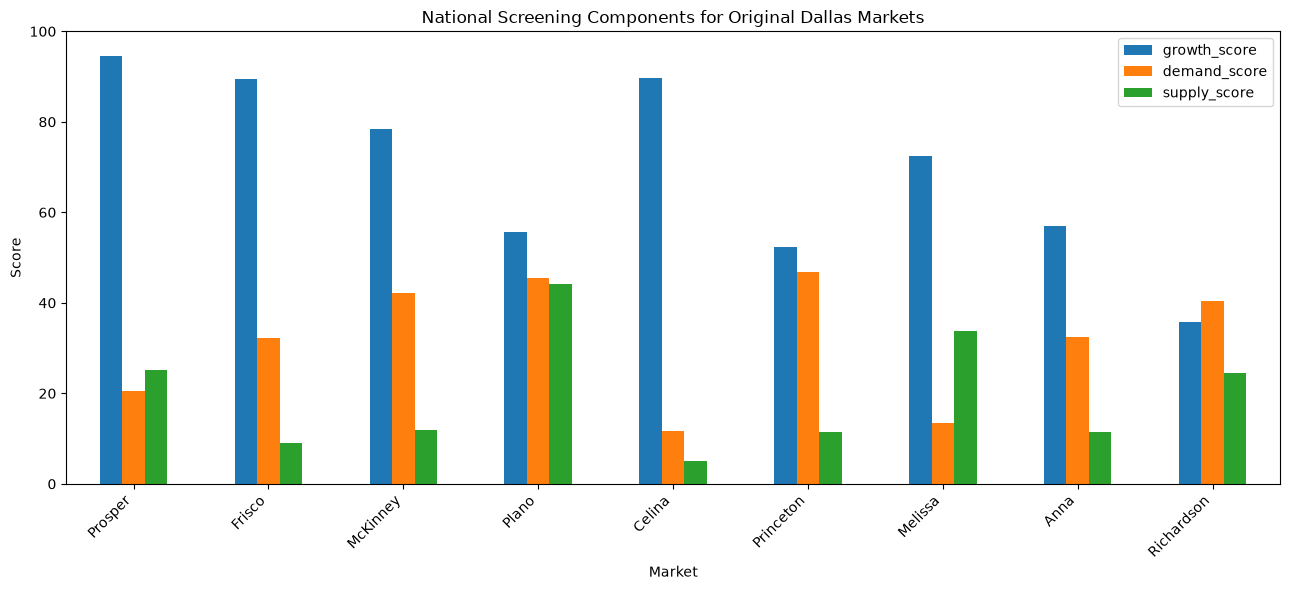

In [29]:
component_plot = comparison[
    [
        "city",
        "growth_score",
        "demand_score",
        "supply_score",
    ]
].copy()

component_plot = component_plot.set_index("city")

ax = component_plot.plot(
    kind="bar",
    figsize=(13, 6),
)

ax.set_title(
    "National Screening Components for Original Dallas Markets"
)
ax.set_xlabel("Market")
ax.set_ylabel("Score")
ax.set_ylim(0, 100)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    PROCESSED_DATA_DIR
    / "dallas_national_score_components.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# Export the national/local reconciliation table

final_validation_table = comparison[
    [
        "city",
        "National_Among_9_Rank",
        "Local_Robust_Rank",
        "Rank_Gap",
        "Texas_Robust_Percentile",
        "growth_score",
        "demand_score",
        "supply_score",
        "Long_Term_Fundamentals_Score",
        "Current_Market_Momentum_Score",
        "Robustness_Profile",
        "Current_Market_Regime",
        "Market_Quadrant",
    ]
].copy()

final_validation_table = final_validation_table.rename(
    columns={
        "city": "City",
        "National_Among_9_Rank": "National_Model_Rank",
        "Local_Robust_Rank": "Local_Model_Rank",
        "Texas_Robust_Percentile": "Texas_Percentile",
        "growth_score": "National_Growth_Score",
        "demand_score": "National_Demand_Score",
        "supply_score": "National_Supply_Score",
    }
)

final_validation_table = (
    final_validation_table
    .sort_values("National_Model_Rank")
    .reset_index(drop=True)
)

final_validation_table

,City,National_Model_Rank,Local_Model_Rank,Rank_Gap,Texas_Percentile,National_Growth_Score,National_Demand_Score,National_Supply_Score,Long_Term_Fundamentals_Score,Current_Market_Momentum_Score,Robustness_Profile,Current_Market_Regime,Market_Quadrant
0,Prosper,1,8,-7,91.09,94.63,20.63,25.25,57.26,31.46,Consistently Lower Ranked,Mixed / Transitional,Long-Term Strength / Weak Current Conditions
1,Frisco,1,6,-5,90.28,89.54,32.32,8.92,48.93,47.92,Consistently Lower Ranked,Relatively Stable,Long-Term Strength / Weak Current Conditions
2,McKinney,3,5,-2,88.66,78.42,42.28,11.92,41.72,57.07,Consistently Lower Ranked,Mixed / Transitional,Strong in Both
3,Plano,4,1,3,80.16,55.56,45.48,44.17,42.94,75.61,Highly Robust,Relatively Stable,Strong in Both
4,Celina,5,4,1,64.78,89.64,11.67,4.99,91.02,21.50,Moderately Robust,Demand Growth / Supply Pressure,Strong in Both
5,Princeton,6,7,-1,61.54,52.43,46.90,11.37,31.07,58.98,Weight Sensitive,Recovery / Repricing,Weaker in Both
6,Melissa,7,2,5,56.28,72.44,13.41,33.73,62.50,54.61,Moderately Robust,Mixed / Transitional,Current Strength / Weaker Structural Score
7,Anna,8,9,-1,45.75,56.90,32.52,11.38,42.75,36.01,Consistently Lower Ranked,Demand Growth / Supply Pressure,Weaker in Both
8,Richardson,9,3,6,29.15,35.70,40.45,24.59,47.27,64.32,Moderately Robust,Relatively Stable,Current Strength / Weaker Structural Score


In [31]:
validation_path = (
    PROCESSED_DATA_DIR
    / "national_local_model_validation.csv"
)

final_validation_table.to_csv(
    validation_path,
    index=False
)

print(f"Saved: {validation_path}")

Saved: ../data/processed/national_local_model_validation.csv


In [32]:
# Export national dataset for dashboard

national_export_path = (
    PROCESSED_DATA_DIR
    / "national_final_decision_table.csv"
)

national_df.to_csv(
    national_export_path,
    index=False
)

print(
    f"Saved {len(national_df):,} national markets to "
    f"{national_export_path}"
)

Saved 2,906 national markets to ../data/processed/national_final_decision_table.csv


In [33]:
# Export Texas subset

texas_export = (
    national_df[
        national_df["state_code"] == "TX"
    ]
    .sort_values("state_robust_rank")
    .copy()
)

texas_export_path = (
    PROCESSED_DATA_DIR
    / "texas_final_decision_table.csv"
)

texas_export.to_csv(
    texas_export_path,
    index=False
)

print(
    f"Saved {len(texas_export):,} Texas markets to "
    f"{texas_export_path}"
)

Saved 248 Texas markets to ../data/processed/texas_final_decision_table.csv


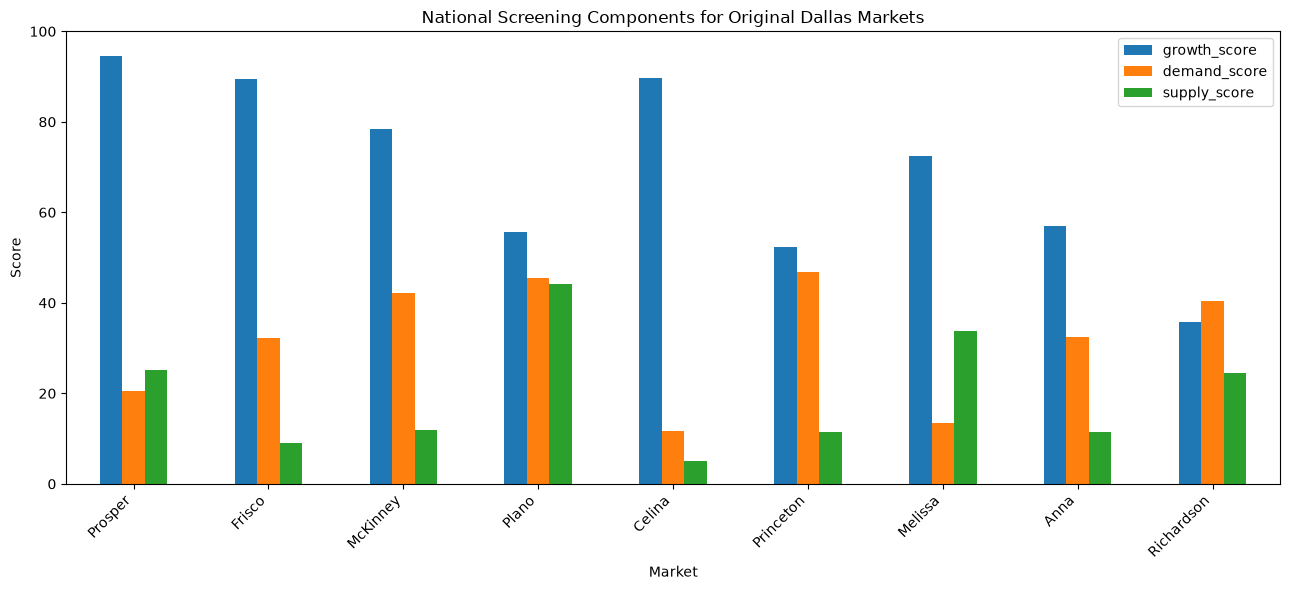

Saved: ../data/processed/dallas_national_score_components.png


In [35]:
# Final score component chart

component_plot = comparison[
    [
        "city",
        "growth_score",
        "demand_score",
        "supply_score",
    ]
].copy()

component_plot = component_plot.set_index("city")

ax = component_plot.plot(
    kind="bar",
    figsize=(13, 6),
)

ax.set_title(
    "National Screening Components for Original Dallas Markets"
)
ax.set_xlabel("Market")
ax.set_ylabel("Score")
ax.set_ylim(0, 100)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

component_chart_path = (
    PROCESSED_DATA_DIR
    / "dallas_national_score_components.png"
)

plt.savefig(
    component_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {component_chart_path}")

## Model Reconciliation

The national screening model and the Dallas-specific model provide complementary
rather than interchangeable views of market attractiveness.

The national model emphasizes structural characteristics including long-term
population growth, home-value appreciation, demand conditions, and supply pressure
relative to a broad U.S. market universe.

The local Dallas model emphasizes Dallas-specific fundamentals, current market
momentum, market regime, and Monte Carlo ranking robustness.

Across the same nine markets, the models produced a Spearman rank correlation of
-0.167, indicating little rank agreement. This suggests that structural attractiveness
and current local-market strength represent distinct dimensions rather than redundant
signals.

### Market Groups

- **Strong in Both:** Plano, Celina, McKinney
- **Long-Term Strength / Weak Current Conditions:** Prosper, Frisco
- **Current Strength / Weaker Structural Score:** Melissa, Richardson
- **Weaker in Both:** Princeton, Anna

These groups are relative to the nine-market comparison universe and should be treated
as screening categories rather than investment recommendations.

In [36]:
# FINAL NOTEBOOK VALIDATION

required_files = [
    "dallas_market_scores.csv",
    "dallas_ranking_robustness.csv",
    "dallas_market_diagnostics.csv",
    "dallas_final_decision_table.csv",
    "tx_local_model_scores.csv",
    "national_local_model_validation.csv",
    "national_final_decision_table.csv",
    "texas_final_decision_table.csv",
    "structural_vs_local_market_strength.png",
    "dallas_national_score_components.png",
]

all_present = True

for filename in required_files:
    path = PROCESSED_DATA_DIR / filename
    exists = path.exists()

    print(
        f"{filename:<45}"
        f"Exists: {exists}"
    )

    if not exists:
        all_present = False

print()
print(
    "Notebook validation:",
    "PASSED" if all_present else "FAILED"
)

dallas_market_scores.csv                     Exists: True
dallas_ranking_robustness.csv                Exists: True
dallas_market_diagnostics.csv                Exists: True
dallas_final_decision_table.csv              Exists: True
tx_local_model_scores.csv                    Exists: True
national_local_model_validation.csv          Exists: True
national_final_decision_table.csv            Exists: True
texas_final_decision_table.csv               Exists: True
structural_vs_local_market_strength.png      Exists: True
dallas_national_score_components.png         Exists: True

Notebook validation: PASSED
